# Width-Scaling SGD Experiments

Train parity networks at widths `N = 256, 512, 1024, 2048` with SGD, save train/test curves, and analyze the final checkpoints with PCA rank reduction and weight-variance scaling.


## Setup

Mount Google Drive, clone the public repo, install it in editable mode, and define the run/plot directories.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [53]:
from pathlib import Path

GITHUB_REPO_URL = "https://github.com/labofdoubt/feature-learning-parity-task.git"
REPO_DIR = Path("/content/feature-learning-parity-task")

# DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_unfrozen_emb_mup")
DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_mup_4blocks_wd_1e-3")

RUNS_DIR = DRIVE_ROOT / "runs"
PLOTS_DIR = DRIVE_ROOT / "plots"
ANALYSIS_DIR = DRIVE_ROOT / "analysis"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
!rm -rf "$REPO_DIR"
!git clone "$GITHUB_REPO_URL" "$REPO_DIR"
%cd "$REPO_DIR"
!pip install -e .

Cloning into '/content/feature-learning-parity-task'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 119 (delta 68), reused 98 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 1.65 MiB | 8.39 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/feature-learning-parity-task
Obtaining file:///content/feature-learning-parity-task
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for parity-net (pyproject.toml) ... done
  Created wheel for parity-net: filename=parity_net-0.1.0-0.editable-py3-none-any.whl size=3070 sha256=49c30d5aa064818cb969b1f0c74a38b121783ba0a5c449a1869438935d32fcc1
  Stored in directory: /tmp/pip-ephem-wheel-cache-dp8ruh9i/wheels/a2/05/6b/5da726f55833c1e289bd27eaf

## Train Width Sweep

This cell writes one config per width and runs training inside the notebook kernel so the progress bar renders in Colab. Existing final checkpoints are skipped unless `FORCE_RETRAIN = True`.


In [54]:
from pathlib import Path

import yaml

from parity_net.config import load_config
from parity_net.train import train

WIDTHS = [256, 512, 1024, 2048]
FORCE_RETRAIN = False


def make_config(N: int, output_dir: Path) -> dict:
    return {
        "model": {
            "input_dim": 32,
            "relevant_dim": 16,
            "N": N,
            "L": 4,
            "activation": "half-tanh",
            "use_readout_barrier": False,
            "embedding_weight_variance": 1.0 / 32,
            "freeze_embedding": False,
            "hidden_weight_variance": 1.0 / N,
            "readout_weight_variance": 1.0 / N,
            "use_post_activation_linear": False,
            "bias": False,
        },
        "training": {
            "num_steps": 100_000,
            "test_samples": 100_000,
            "batch_size": 512,
            "seed": 0,
            "device": "cuda",
            "dtype": "float32",
            "log_every": 1_000,
            "checkpoint_every": 1_000,
            "output_dir": str(output_dir),
            "barrier_c": None,
            "barrier_lambda": 10.0,
            "optimizer": {
                "name": "sgd",
                "lr": 1e-2,
                "lr_embedding": None,
                "lr_hidden": None,
                "lr_readout": None,
                "weight_decay": 1e-3,
                "wd_embedding": None,
                "wd_hidden": None,
                "wd_readout": None,
                "momentum": 0.9,
                "betas": [0.9, 0.999],
            },
        },
    }


def make_config_mup(N: int, output_dir: Path) -> dict:
    config = make_config(N, output_dir)
    optimizer = config["training"]["optimizer"]
    base_lr = optimizer["lr"]
    base_wd = optimizer["weight_decay"]
    config["model"]["readout_weight_variance"] = 1 / N**2
    optimizer["lr_embedding"] = base_lr * N / 256
    optimizer["lr_hidden"] = base_lr
    optimizer["lr_readout"] = base_lr * 256 / N
    optimizer["wd_embedding"] = base_wd * 256 / N
    optimizer["wd_hidden"] = base_wd
    optimizer["wd_readout"] = base_wd * N / 256
    return config


CONFIG_FACTORY = make_config_mup  # Change to make_config_mup for the muP-scaled sweep.


In [55]:
config_paths = {}
for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    run_dir.mkdir(parents=True, exist_ok=True)
    config_path = run_dir / "config.yaml"
    final_checkpoint = run_dir / "checkpoints" / "final.pt"

    if final_checkpoint.exists() and not FORCE_RETRAIN:
        config_paths[N] = config_path
        print(
            f"N={N}: final checkpoint exists, skipping training: {final_checkpoint}. "
            "Set FORCE_RETRAIN=True or choose a new DRIVE_ROOT to train with changed config values."
        )
        continue

    config = CONFIG_FACTORY(N, run_dir)
    with config_path.open("w") as f:
        yaml.safe_dump(config, f, sort_keys=False)
    config_paths[N] = config_path

    print(f"N={N}: training with {config_path}")
    final_path = train(load_config(config_path))
    print(f"N={N}: saved final checkpoint to {final_path}")


N=256: training with /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_mup_4blocks_wd_1e-3/runs/N_256/config.yaml


TypeError: OptimizerConfig.__init__() got an unexpected keyword argument 'wd_embedding'

## Train/Test Curves

Read `metrics.csv` from each run, save one plot per width, and save combined train/test plots across widths.


In [5]:
# DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_unfrozen_emb")
# DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd")

RUNS_DIR = DRIVE_ROOT / "runs"
PLOTS_DIR = DRIVE_ROOT / "plots"
ANALYSIS_DIR = DRIVE_ROOT / "analysis"

WIDTHS = [256, 512, 1024, 2048, 4096]

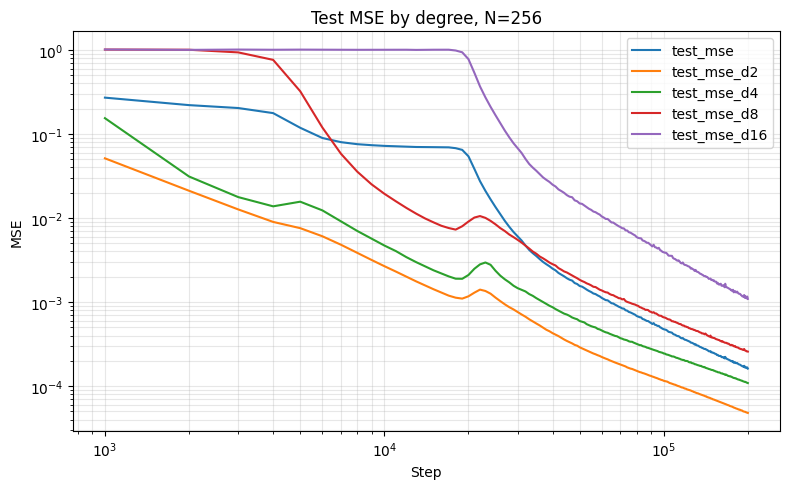

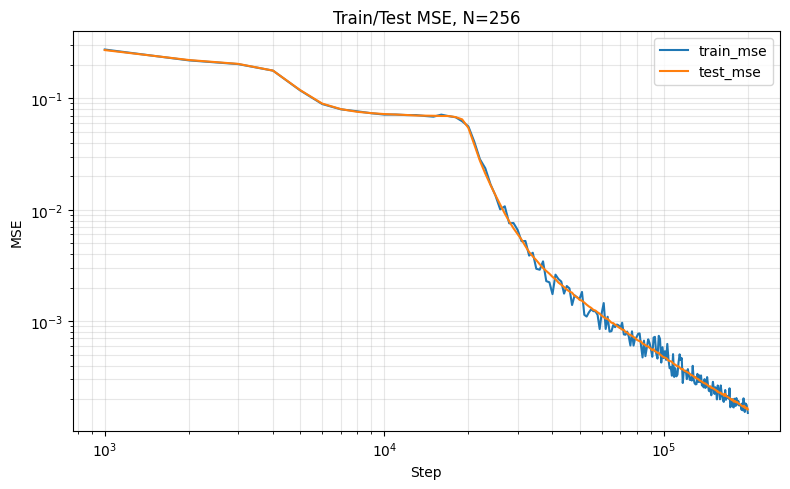

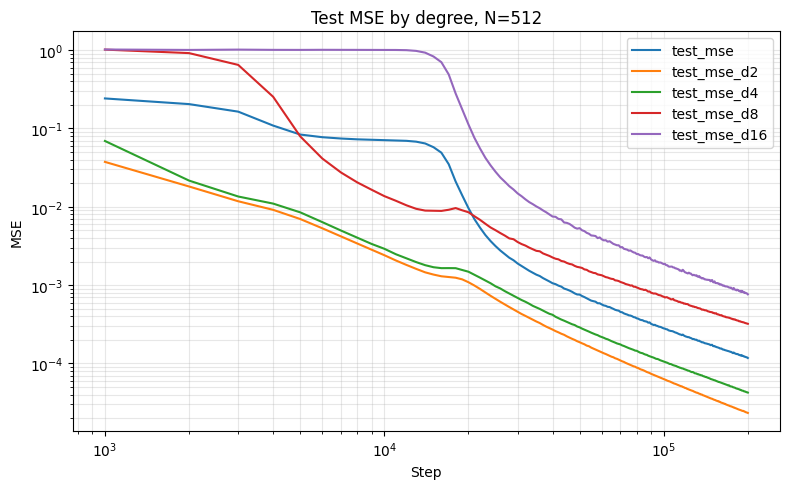

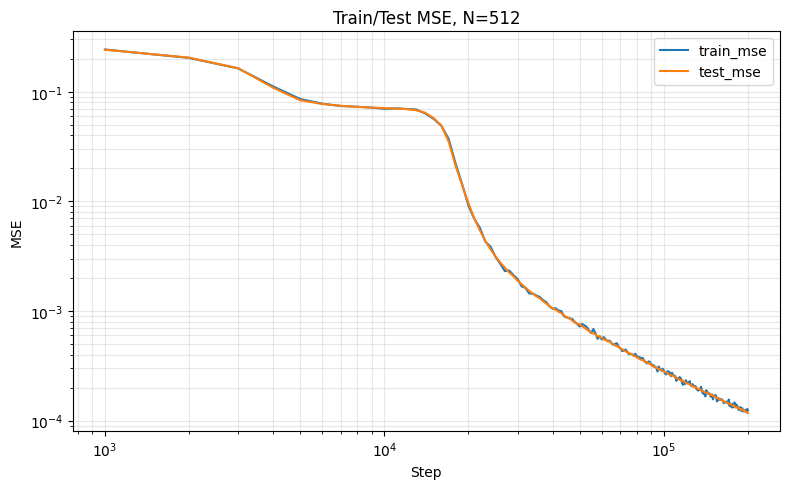

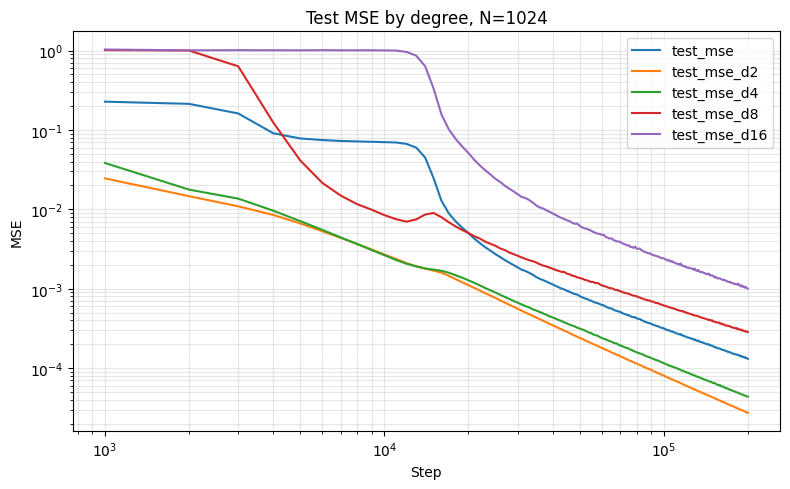

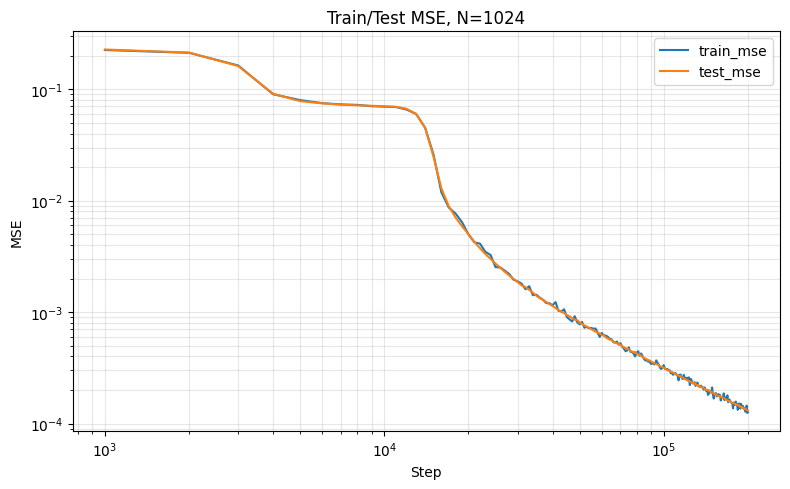

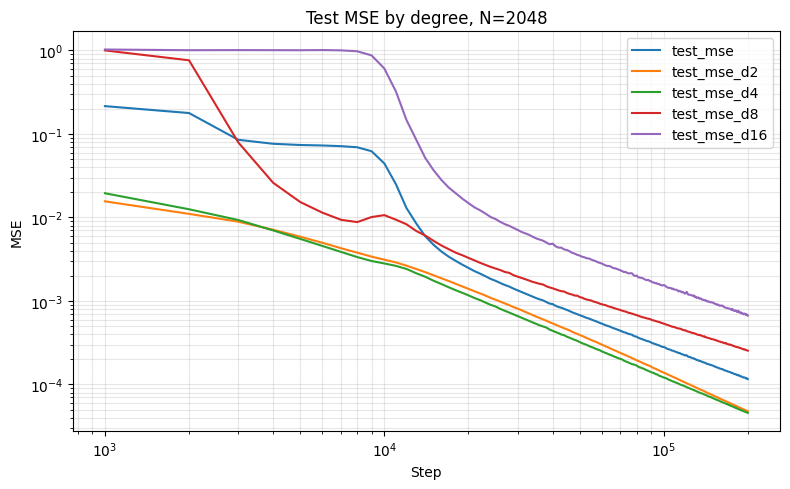

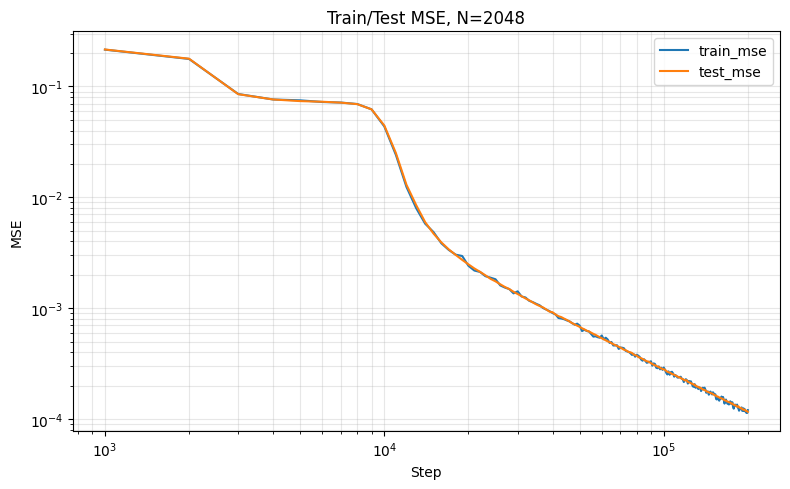

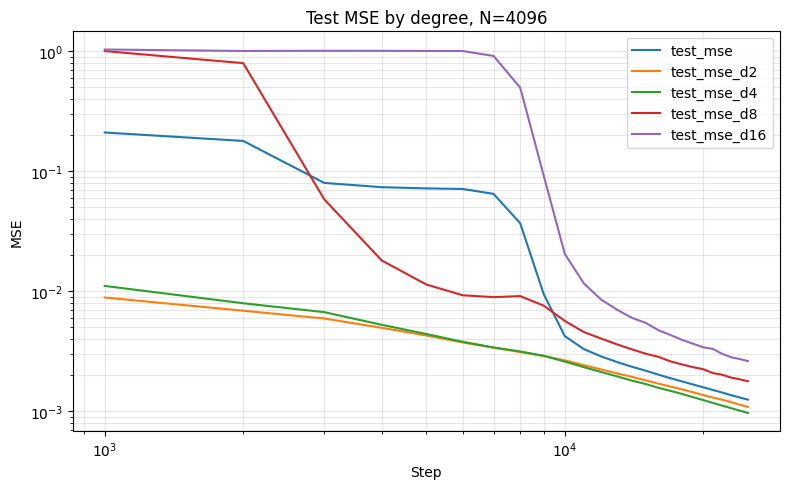

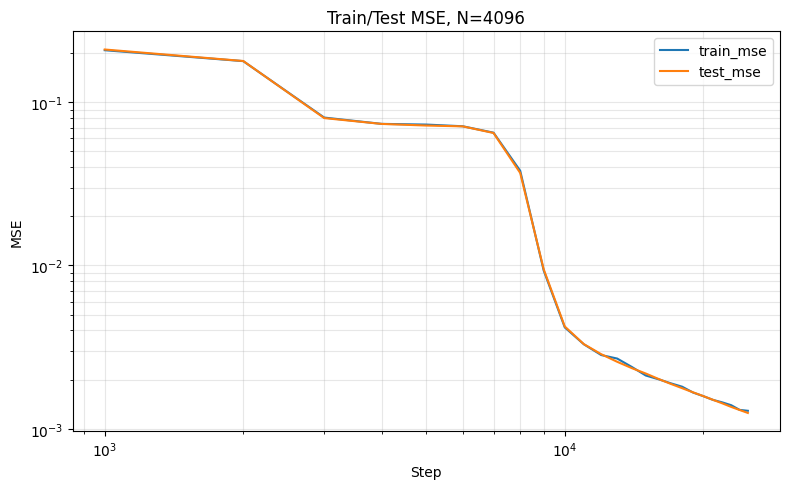

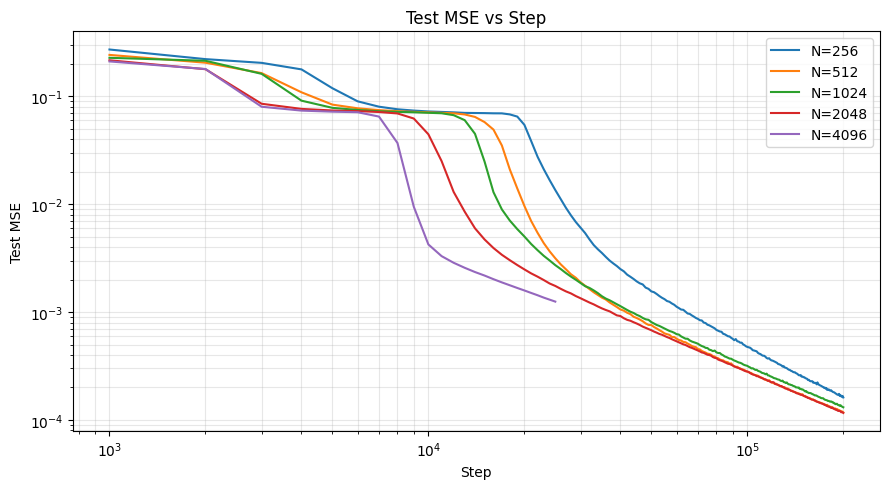

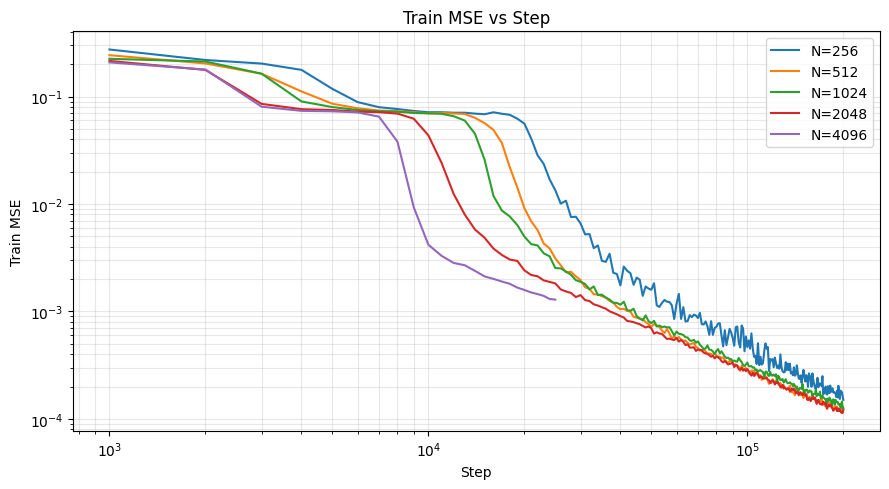

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

USE_LOG_MSE_AXIS = True
USE_LOG_STEP_AXIS = True
TEST_MSE_COLUMNS = ["test_mse", "test_mse_d2", "test_mse_d4", "test_mse_d8", "test_mse_d16"]


def axis_has_positive_data(ax, axis):
    for line in ax.lines:
        values = line.get_xdata() if axis == "x" else line.get_ydata()
        if len(values) and pd.Series(values).dropna().gt(0).any():
            return True
    return False


def maybe_log_y(ax):
    if USE_LOG_MSE_AXIS and axis_has_positive_data(ax, "y"):
        ax.set_yscale("log")


def maybe_log_x(ax):
    if USE_LOG_STEP_AXIS and axis_has_positive_data(ax, "x"):
        ax.set_xscale("log")


metrics_by_width = {}
for N in WIDTHS:
    metrics_path = RUNS_DIR / f"N_{N}" / "metrics.csv"
    if not metrics_path.exists():
        print(f"N={N}: missing {metrics_path}")
        continue
    df = pd.read_csv(metrics_path)
    metrics_by_width[N] = df

    fig, ax = plt.subplots(figsize=(8, 5))
    for column in TEST_MSE_COLUMNS:
        if column in df.columns:
            ax.plot(df["step"], df[column], label=column)
    ax.set_xlabel("Step")
    ax.set_ylabel("MSE")
    ax.set_title(f"Test MSE by degree, N={N}")
    maybe_log_x(ax)
    maybe_log_y(ax)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"test_mse_by_degree_N_{N}.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["step"], df["train_mse"], label="train_mse")
    ax.plot(df["step"], df["test_mse"], label="test_mse")
    ax.set_xlabel("Step")
    ax.set_ylabel("MSE")
    ax.set_title(f"Train/Test MSE, N={N}")
    maybe_log_x(ax)
    maybe_log_y(ax)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"train_test_mse_N_{N}.png", dpi=150)
    plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for N, df in metrics_by_width.items():
    ax.plot(df["step"], df["test_mse"], label=f"N={N}")
ax.set_xlabel("Step")
ax.set_ylabel("Test MSE")
ax.set_title("Test MSE vs Step")
maybe_log_x(ax)
maybe_log_y(ax)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "test_mse_by_width.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for N, df in metrics_by_width.items():
    ax.plot(df["step"], df["train_mse"], label=f"N={N}")
ax.set_xlabel("Step")
ax.set_ylabel("Train MSE")
ax.set_title("Train MSE vs Step")
maybe_log_x(ax)
maybe_log_y(ax)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "train_mse_by_width.png", dpi=150)
plt.show()


## Final-Checkpoint PCA and Weight-Variance Analysis

For each final checkpoint, load the saved test set, compute PCA ranks at the selected residual-stream layer, sweep PCA interventions, and collect trained weight variances.


N=256: collecting activations from 20000 saved test samples


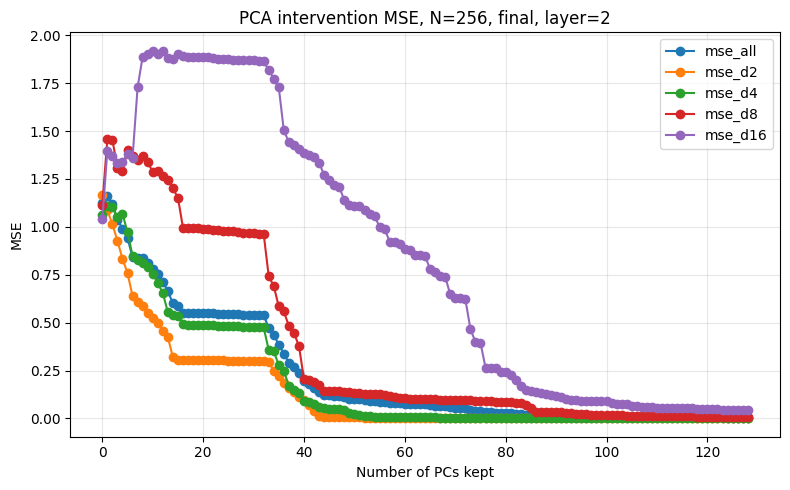

N=512: collecting activations from 20000 saved test samples


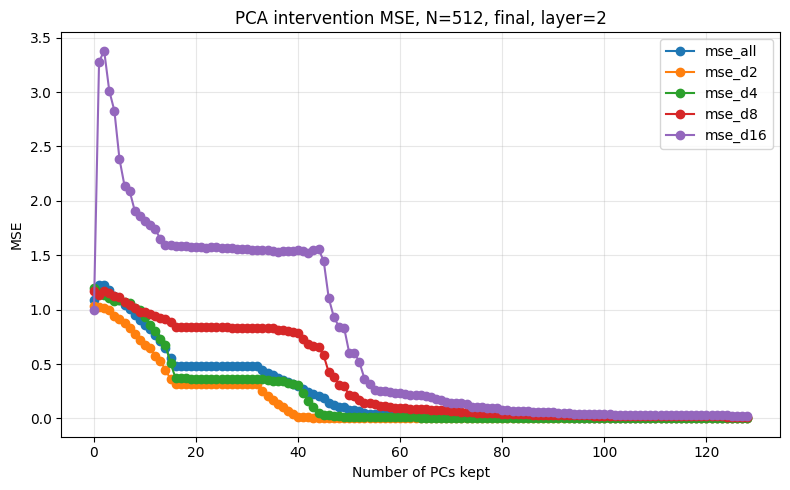

N=1024: collecting activations from 20000 saved test samples


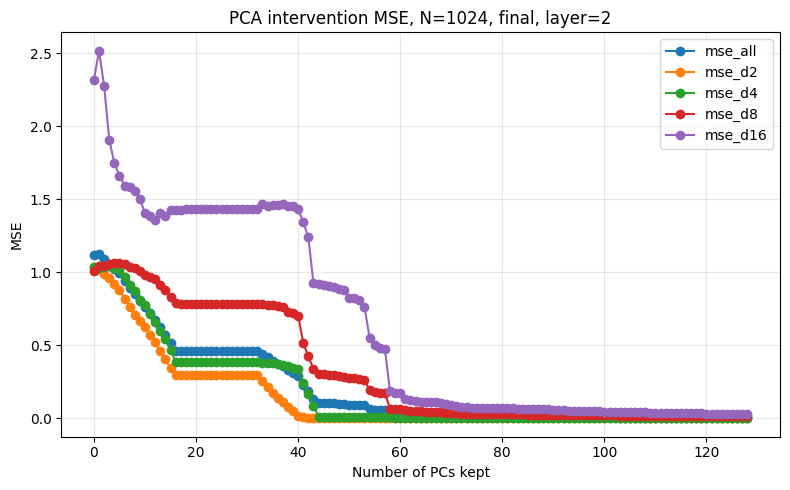

N=2048: collecting activations from 20000 saved test samples


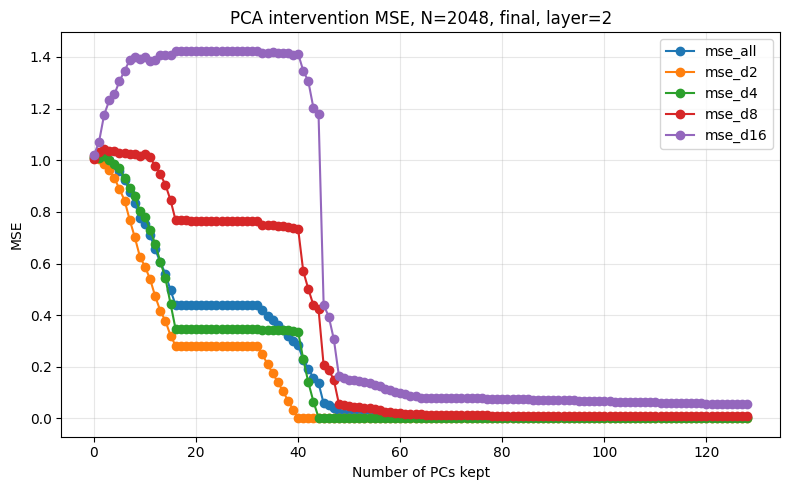

N=4096: missing checkpoint /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_mup_4blocks/runs/N_4096/checkpoints/final.pt, skipping analysis


,N,checkpoint,layer_idx,rank_90,rank_99,num_dimensions
0,256,final,0,27,32,256
1,256,final,1,27,41,256
2,256,final,2,28,53,256
3,256,final,3,30,70,256
4,256,final,4,32,88,256
5,512,final,0,27,32,512
6,512,final,1,27,47,512
7,512,final,2,28,89,512
8,512,final,3,30,140,512
9,512,final,4,32,181,512


,N,checkpoint,layer,variance
0,256,final,embedding.weight,0.029922
1,256,final,blocks.0.linear.weight,0.003887
2,256,final,blocks.1.linear.weight,0.004001
3,256,final,blocks.2.linear.weight,0.003950
4,256,final,blocks.3.linear.weight,0.004052
5,256,final,readout.weight,0.013456
6,512,final,embedding.weight,0.029652
7,512,final,blocks.0.linear.weight,0.001946
8,512,final,blocks.1.linear.weight,0.001939
9,512,final,blocks.2.linear.weight,0.001981


Skipped widths


,N,reason
0,4096,missing checkpoint


In [7]:
import torch

from parity_net.analysis import (
    collect_layer_activations,
    make_pca_intervention,
    pca_from_activations,
    per_degree_mse,
    predict_in_batches,
    rank_for_threshold,
)
from parity_net.checkpoint import load_checkpoint
from parity_net.data import ParityDataset, load_dataset
from parity_net.train import resolve_device, resolve_dtype

PCA_SAMPLES = 20_000
CHECKPOINT_STEP = "final"  # Use "final" or an integer step, e.g. 50000.
USE_LOG_PCA_MSE_AXIS = False
ANALYSIS_LAYER_IDX = 2  # 0 is embedding, later indices are after residual blocks.
KEEP_PCS_MIN = 0
KEEP_PCS_MAX = 128
KEEP_PCS_STEP = 1


def checkpoint_name(checkpoint_step):
    if checkpoint_step == "final":
        return "final.pt", "final"
    if isinstance(checkpoint_step, int):
        return f"step_{checkpoint_step:08d}.pt", f"step_{checkpoint_step:08d}"
    raise ValueError('CHECKPOINT_STEP must be "final" or an integer step')


def assert_finite_tensor(tensor, label):
    if not torch.isfinite(tensor).all().item():
        raise ValueError(f"{label} contains NaN or Inf")


def assert_finite_metrics(metrics, label):
    bad = {key: value for key, value in metrics.items() if not pd.notna(value)}
    if bad:
        raise ValueError(f"{label} contains non-finite values: {bad}")


checkpoint_file, checkpoint_label = checkpoint_name(CHECKPOINT_STEP)
rank_rows = []
weight_rows = []
pca_sweep_by_width = {}
skipped_widths = []

for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    checkpoint_path = run_dir / "checkpoints" / checkpoint_file
    if not checkpoint_path.exists():
        print(f"N={N}: missing checkpoint {checkpoint_path}, skipping analysis")
        skipped_widths.append({"N": N, "reason": "missing checkpoint"})
        continue

    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model, payload, _ = load_checkpoint(checkpoint_path, device)
        training = payload["config"]["training"]
        model_config = payload["config"]["model"]
        device = resolve_device(training["device"])
        dtype = resolve_dtype(training["dtype"])
        model = model.to(device=device, dtype=dtype)
        batch_size = training["batch_size"]

        test_data_path = Path(payload.get("test_data_path") or run_dir / "test_data.pt")
        test_data = load_dataset(test_data_path, device, dtype)
        if PCA_SAMPLES < test_data.x.shape[0]:
            heldout = ParityDataset(x=test_data.x[:PCA_SAMPLES], y=test_data.y[:PCA_SAMPLES])
        else:
            heldout = test_data

        local_weight_rows = []
        for layer, variance in model.weight_variances().items():
            if not pd.notna(variance):
                raise ValueError(f"weight variance for {layer} is non-finite: {variance}")
            local_weight_rows.append({"N": N, "checkpoint": checkpoint_label, "layer": layer, "variance": variance})

        print(f"N={N}: collecting activations from {heldout.x.shape[0]} saved test samples")
        activations = collect_layer_activations(model, heldout.x, batch_size)
        for layer_idx, layer_acts in enumerate(activations):
            assert_finite_tensor(layer_acts, f"N={N} activations layer {layer_idx}")

        pcas = [pca_from_activations(layer_acts) for layer_acts in activations]
        for layer_idx, pca in enumerate(pcas):
            assert_finite_tensor(pca["cumulative_explained_variance"], f"N={N} PCA cumulative layer {layer_idx}")
            assert_finite_tensor(pca["components"], f"N={N} PCA components layer {layer_idx}")

        local_rank_rows = []
        for layer_idx, pca in enumerate(pcas):
            cumulative = pca["cumulative_explained_variance"]
            local_rank_rows.append(
                {
                    "N": N,
                    "checkpoint": checkpoint_label,
                    "layer_idx": layer_idx,
                    "rank_90": rank_for_threshold(cumulative, 0.90),
                    "rank_99": rank_for_threshold(cumulative, 0.99),
                    "num_dimensions": cumulative.numel(),
                }
            )

        if ANALYSIS_LAYER_IDX < 0 or ANALYSIS_LAYER_IDX >= len(pcas):
            raise ValueError(f"ANALYSIS_LAYER_IDX must be in [0, {len(pcas) - 1}]")

        max_available_pcs = pcas[ANALYSIS_LAYER_IDX]["components"].shape[0]
        keep_pcs_max_effective = min(KEEP_PCS_MAX, max_available_pcs)
        keep_pcs_values = list(range(KEEP_PCS_MIN, keep_pcs_max_effective + 1, KEEP_PCS_STEP))
        if keep_pcs_values[-1] != keep_pcs_max_effective:
            keep_pcs_values.append(keep_pcs_max_effective)

        sweep_rows = []
        for keep_pcs in keep_pcs_values:
            intervention = make_pca_intervention(pcas[ANALYSIS_LAYER_IDX], keep_pcs)
            with torch.no_grad():
                pred_intervened = predict_in_batches(
                    model,
                    heldout.x,
                    batch_size,
                    intervention=(ANALYSIS_LAYER_IDX, intervention),
                )
            assert_finite_tensor(pred_intervened, f"N={N} intervened predictions keep_pcs={keep_pcs}")
            metrics = per_degree_mse(pred_intervened, heldout.y)
            assert_finite_metrics(metrics, f"N={N} MSE metrics keep_pcs={keep_pcs}")
            sweep_rows.append(
                {
                    "N": N,
                    "checkpoint": checkpoint_label,
                    "intervention_layer": ANALYSIS_LAYER_IDX,
                    "keep_pcs": keep_pcs,
                    **metrics,
                }
            )

        sweep_df = pd.DataFrame(sweep_rows)
        pca_sweep_by_width[N] = sweep_df
        sweep_df.to_csv(ANALYSIS_DIR / f"pca_mse_sweep_{checkpoint_label}_N_{N}.csv", index=False)

        fig, ax = plt.subplots(figsize=(8, 5))
        sweep_df.plot(
            x="keep_pcs",
            y=["mse_all", "mse_d2", "mse_d4", "mse_d8", "mse_d16"],
            marker="o",
            ax=ax,
        )
        ax.set_xlabel("Number of PCs kept")
        ax.set_ylabel("MSE")
        ax.set_title(f"PCA intervention MSE, N={N}, {checkpoint_label}, layer={ANALYSIS_LAYER_IDX}")
        if USE_LOG_PCA_MSE_AXIS:
            ax.set_yscale("log")
        ax.grid(True, alpha=0.3, which="both")
        fig.tight_layout()
        fig.savefig(PLOTS_DIR / f"pca_mse_sweep_{checkpoint_label}_layer_{ANALYSIS_LAYER_IDX}_N_{N}.png", dpi=150)
        plt.show()

        weight_rows.extend(local_weight_rows)
        rank_rows.extend(local_rank_rows)

    except Exception as exc:
        print(f"N={N}: checkpoint {checkpoint_path} is broken or non-finite, skipping. Reason: {exc}")
        skipped_widths.append({"N": N, "reason": str(exc)})
        plt.close("all")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        continue

rank_df = pd.DataFrame(rank_rows)
weight_variance_df = pd.DataFrame(weight_rows)
skipped_widths_df = pd.DataFrame(skipped_widths)
rank_df.to_csv(ANALYSIS_DIR / f"pca_ranks_by_width_{checkpoint_label}.csv", index=False)
weight_variance_df.to_csv(ANALYSIS_DIR / f"weight_variances_by_width_{checkpoint_label}.csv", index=False)
skipped_widths_df.to_csv(ANALYSIS_DIR / f"skipped_widths_{checkpoint_label}.csv", index=False)

display(rank_df)
display(weight_variance_df)
if not skipped_widths_df.empty:
    print("Skipped widths")
    display(skipped_widths_df)


## Summary Plots

Plot effective residual-stream dimension versus width, PCA intervention curves across widths, and trained weight variance scaling versus width.


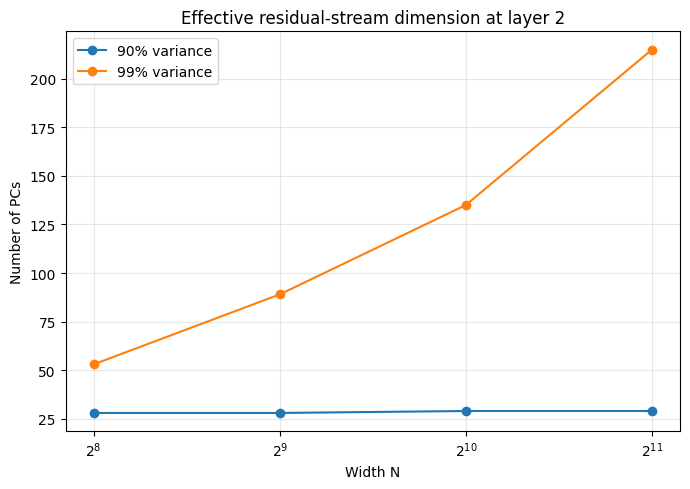

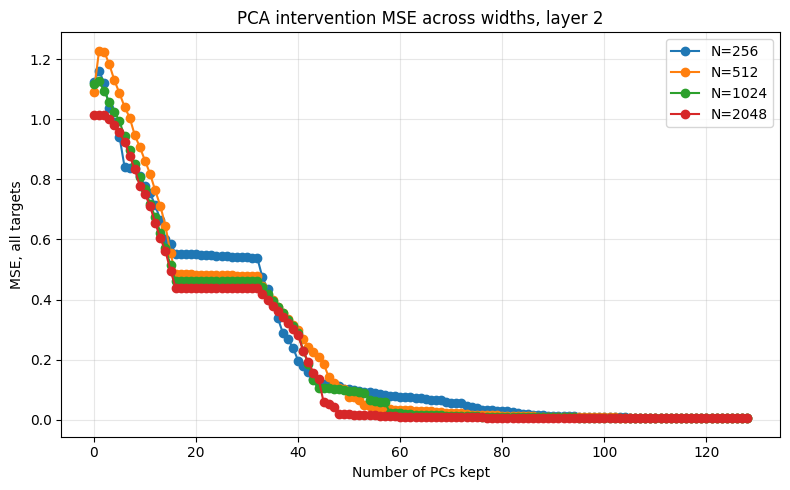

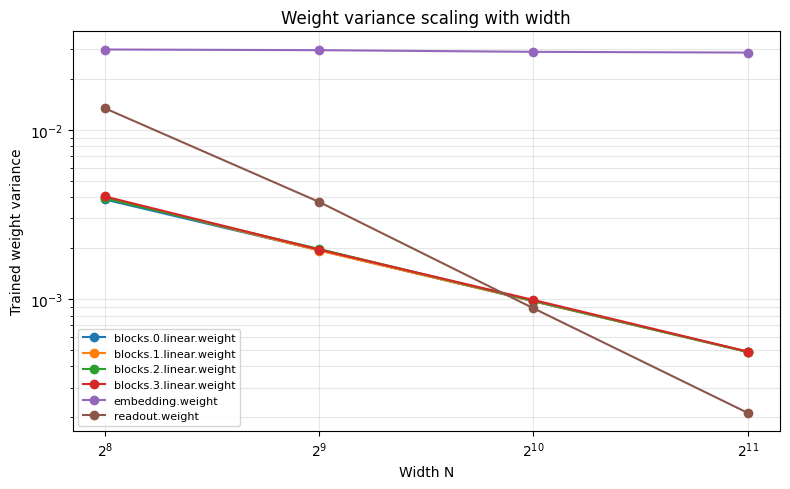

In [9]:
layer_rank_df = rank_df[rank_df["layer_idx"] == ANALYSIS_LAYER_IDX].copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(layer_rank_df["N"], layer_rank_df["rank_90"], marker="o", label="90% variance")
ax.plot(layer_rank_df["N"], layer_rank_df["rank_99"], marker="o", label="99% variance")
ax.set_xscale("log", base=2)
ax.set_xlabel("Width N")
ax.set_ylabel("Number of PCs")
ax.set_title(f"Effective residual-stream dimension at layer {ANALYSIS_LAYER_IDX}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"effective_dimension_vs_width_layer_{ANALYSIS_LAYER_IDX}.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for N, sweep_df in pca_sweep_by_width.items():
    ax.plot(sweep_df["keep_pcs"], sweep_df["mse_all"], marker="o", label=f"N={N}")
ax.set_xlabel("Number of PCs kept")
ax.set_ylabel("MSE, all targets")
ax.set_title(f"PCA intervention MSE across widths, layer {ANALYSIS_LAYER_IDX}")
if USE_LOG_PCA_MSE_AXIS:
    ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"pca_mse_all_sweep_by_width_layer_{ANALYSIS_LAYER_IDX}.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for layer, group in weight_variance_df.groupby("layer"):
    group = group.sort_values("N")
    ax.plot(group["N"], group["variance"], marker="o", label=layer)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Width N")
ax.set_ylabel("Trained weight variance")
ax.set_title("Weight variance scaling with width")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"weight_variance_vs_width_layer_{ANALYSIS_LAYER_IDX}.png", dpi=150)
plt.show()


## Activation Variance vs Width

For one saved test sample, plot the variance across coordinates of each activation vector after the embedding, after each residual block, and after the readout as a function of width.


N=4096: missing checkpoint /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_mup_4blocks/runs/N_4096/checkpoints/final.pt, skipping activation variance


,N,checkpoint,layer_idx,layer,variance
0,256,final,0,embedding,0.962953
1,256,final,1,block_1,1.110943
2,256,final,2,block_2,1.239484
3,256,final,3,block_3,1.371991
4,256,final,4,block_4,1.541916
5,256,final,5,readout,0.990620
6,512,final,0,embedding,0.911758
7,512,final,1,block_1,1.079952
8,512,final,2,block_2,1.256979
9,512,final,3,block_3,1.474817


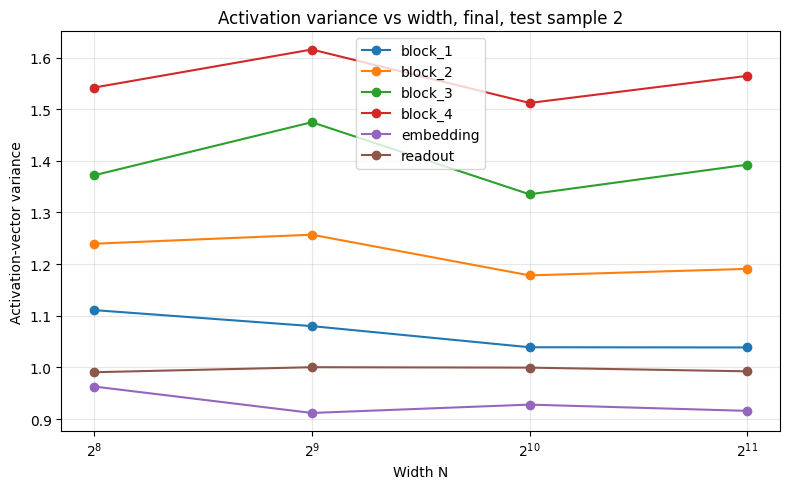

In [13]:
ACTIVATION_SAMPLE_IDX = 2
ACTIVATION_CHECKPOINT_STEP = "final"  # Use "final" or an integer step.

from parity_net.checkpoint import load_checkpoint
from parity_net.data import load_dataset
from parity_net.train import resolve_device, resolve_dtype


def activation_checkpoint_name(checkpoint_step):
    if checkpoint_step == "final":
        return "final.pt", "final"
    if isinstance(checkpoint_step, int):
        return f"step_{checkpoint_step:08d}.pt", f"step_{checkpoint_step:08d}"
    raise ValueError('ACTIVATION_CHECKPOINT_STEP must be "final" or an integer step')


activation_checkpoint_file, activation_checkpoint_label = activation_checkpoint_name(ACTIVATION_CHECKPOINT_STEP)
activation_variance_rows = []
for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    checkpoint_path = run_dir / "checkpoints" / activation_checkpoint_file
    if not checkpoint_path.exists():
        print(f"N={N}: missing checkpoint {checkpoint_path}, skipping activation variance")
        continue

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, payload, _ = load_checkpoint(checkpoint_path, device)
    training = payload["config"]["training"]
    device = resolve_device(training["device"])
    dtype = resolve_dtype(training["dtype"])
    model = model.to(device=device, dtype=dtype)

    test_data_path = Path(payload.get("test_data_path") or run_dir / "test_data.pt")
    test_data = load_dataset(test_data_path, device, dtype)
    if ACTIVATION_SAMPLE_IDX < 0 or ACTIVATION_SAMPLE_IDX >= test_data.x.shape[0]:
        raise ValueError(
            f"ACTIVATION_SAMPLE_IDX={ACTIVATION_SAMPLE_IDX} is outside saved test set "
            f"of size {test_data.x.shape[0]} for N={N}"
        )

    x_sample = test_data.x[ACTIVATION_SAMPLE_IDX : ACTIVATION_SAMPLE_IDX + 1]
    model.eval()
    with torch.no_grad():
        readout, activations = model(x_sample, return_activations=True)

    for layer_idx, h in enumerate(activations):
        layer_name = "embedding" if layer_idx == 0 else f"block_{layer_idx}"
        activation_variance_rows.append(
            {
                "N": N,
                "checkpoint": activation_checkpoint_label,
                "layer_idx": layer_idx,
                "layer": layer_name,
                "variance": h.squeeze(0).detach().float().var(unbiased=False).item(),
            }
        )

    activation_variance_rows.append(
        {
            "N": N,
            "checkpoint": activation_checkpoint_label,
            "layer_idx": len(activations),
            "layer": "readout",
            "variance": readout.squeeze(0).detach().float().var(unbiased=False).item(),
        }
    )

activation_variance_by_width_df = pd.DataFrame(activation_variance_rows)
activation_variance_by_width_df.to_csv(
    ANALYSIS_DIR / f"activation_variance_by_width_{activation_checkpoint_label}.csv",
    index=False,
)
display(activation_variance_by_width_df)

fig, ax = plt.subplots(figsize=(8, 5))
for layer, group in activation_variance_by_width_df.groupby("layer"):
    group = group.sort_values("N")
    ax.plot(group["N"], group["variance"], marker="o", label=layer)
ax.set_xscale("log", base=2)
ax.set_xlabel("Width N")
ax.set_ylabel("Activation-vector variance")
ax.set_title(
    f"Activation variance vs width, {activation_checkpoint_label}, "
    f"test sample {ACTIVATION_SAMPLE_IDX}"
)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"activation_variance_by_width_{activation_checkpoint_label}.png", dpi=150)
plt.show()


In [1]:
run_dir_ = run_dir.parent / "N_2048"

ckpt_a = torch.load(run_dir_/ "checkpoints" / "step_00001000.pt", map_location="cpu")
ckpt_b = torch.load(run_dir_/ "checkpoints" / "final.pt", map_location="cpu")

w_a = ckpt_a["model_state"]["embedding.weight"]
w_b = ckpt_b["model_state"]["embedding.weight"]

print("embedding delta norm:", (w_b - w_a).norm().item())
print("relative delta:", (w_b - w_a).norm().item() / w_a.norm().item())

NameError: name 'run_dir' is not defined

## Neuron-Target Correlations

Load a checkpoint from the run directory for a chosen width `N`, compute Pearson correlations between each neuron activation and each saved-test-set target, then inspect any selected neuron.


In [10]:
import pandas as pd
import torch

from parity_net.checkpoint import load_checkpoint
from parity_net.data import ParityDataset, load_dataset
from parity_net.train import resolve_device, resolve_dtype

CORRELATION_N = 2048
CORRELATION_CHECKPOINT_STEP = "final"  # Use "final" or an integer step, e.g. 1000.
CORRELATION_SAMPLES = 20_000
CORRELATION_ACTIVATION_SOURCE = "block_nonlinearity"  # "residual_stream" or "block_nonlinearity".

def correlation_checkpoint_name(checkpoint_step):
    if checkpoint_step == "final":
        return "final.pt", "final"
    if isinstance(checkpoint_step, int):
        return f"step_{checkpoint_step:08d}.pt", f"step_{checkpoint_step:08d}"
    raise ValueError('CORRELATION_CHECKPOINT_STEP must be "final" or an integer step')


def collect_correlation_activations(model, x, source):
    if source == "residual_stream":
        _, activations = model(x, return_activations=True)
        layer_names = ["embedding", *[f"after_block_{i}" for i in range(len(model.blocks))]]
        return activations, layer_names

    if source == "block_nonlinearity":
        h = model.embedding(x)
        activations = []
        layer_names = []
        for block_idx, block in enumerate(model.blocks):
            nonlinear = block.activation(block.linear(h))
            activations.append(nonlinear)
            layer_names.append(f"block_{block_idx}_nonlinearity")
            update = nonlinear
            if block.post_activation_linear is not None:
                update = block.post_activation_linear(update)
            h = h + update
        return activations, layer_names

    raise ValueError(
        'CORRELATION_ACTIVATION_SOURCE must be "residual_stream" or "block_nonlinearity"'
    )


correlation_checkpoint_file, correlation_checkpoint_label = correlation_checkpoint_name(
    CORRELATION_CHECKPOINT_STEP
)
correlation_run_dir = RUNS_DIR / f"N_{CORRELATION_N}"
correlation_checkpoint_path = correlation_run_dir / "checkpoints" / correlation_checkpoint_file
if not correlation_checkpoint_path.exists():
    raise FileNotFoundError(f"Missing checkpoint: {correlation_checkpoint_path}")

load_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, payload, _ = load_checkpoint(correlation_checkpoint_path, load_device)
training = payload["config"]["training"]
device = resolve_device(training["device"])
dtype = resolve_dtype(training["dtype"])
model = model.to(device=device, dtype=dtype)
model.eval()

test_data_path = Path(payload.get("test_data_path") or correlation_run_dir / "test_data.pt")
if not test_data_path.exists():
    raise FileNotFoundError(f"Missing saved test data: {test_data_path}")
test_data = load_dataset(test_data_path, device, dtype)
correlation_count = min(CORRELATION_SAMPLES, test_data.x.shape[0])
correlation_data = ParityDataset(
    x=test_data.x[:correlation_count],
    y=test_data.y[:correlation_count],
)

with torch.no_grad():
    correlation_activations, correlation_layer_names = collect_correlation_activations(
        model,
        correlation_data.x,
        CORRELATION_ACTIVATION_SOURCE,
    )

if not correlation_activations:
    raise ValueError(
        f"No activations were collected for source {CORRELATION_ACTIVATION_SOURCE!r}. "
        "This can happen if the model has no residual blocks."
    )

target_columns = [
    *[f"d2_{i}" for i in range(8)],
    *[f"d4_{i}" for i in range(4)],
    *[f"d8_{i}" for i in range(2)],
    "d16_0",
]

if correlation_data.y.shape[1] != len(target_columns):
    raise ValueError(
        f"Expected {len(target_columns)} target labels, got {correlation_data.y.shape[1]} targets"
    )

y = correlation_data.y.detach().float()
y_centered = y - y.mean(dim=0, keepdim=True)
y_norm = torch.linalg.vector_norm(y_centered, dim=0).clamp_min(torch.finfo(y_centered.dtype).eps)

correlation_by_layer = {}
correlation_rows = []
for layer_idx, (h, layer_name) in enumerate(zip(correlation_activations, correlation_layer_names)):
    h = h.detach().float()
    if not torch.isfinite(h).all().item():
        raise ValueError(f"Layer {layer_idx} ({layer_name}) activations contain NaN or Inf")
    h_centered = h - h.mean(dim=0, keepdim=True)
    h_norm = torch.linalg.vector_norm(h_centered, dim=0).clamp_min(torch.finfo(h_centered.dtype).eps)
    corr = (h_centered.T @ y_centered) / (h_norm[:, None] * y_norm[None, :])
    corr_cpu = corr.cpu()
    correlation_by_layer[layer_idx] = corr_cpu
    for neuron_idx in range(corr_cpu.shape[0]):
        row = {
            "N": CORRELATION_N,
            "checkpoint": correlation_checkpoint_label,
            "activation_source": CORRELATION_ACTIVATION_SOURCE,
            "layer_idx": layer_idx,
            "layer": layer_name,
            "neuron_idx": neuron_idx,
            "max_abs_correlation": corr_cpu[neuron_idx].abs().max().item(),
        }
        row.update(
            {
                target: corr_cpu[neuron_idx, target_idx].item()
                for target_idx, target in enumerate(target_columns)
            }
        )
        correlation_rows.append(row)

neuron_target_correlations = pd.DataFrame(correlation_rows)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
correlation_csv_path = (
    ANALYSIS_DIR
    / f"neuron_target_correlations_N_{CORRELATION_N}_{correlation_checkpoint_label}_{CORRELATION_ACTIVATION_SOURCE}.csv"
)
neuron_target_correlations.to_csv(correlation_csv_path, index=False)

print(
    f"Computed {CORRELATION_ACTIVATION_SOURCE} correlations for N={CORRELATION_N}, "
    f"checkpoint={correlation_checkpoint_label}, "
    f"{len(correlation_by_layer)} activation layers, "
    f"{correlation_by_layer[0].shape[0]} neurons per collected layer, "
    f"and {len(target_columns)} targets using {correlation_count} saved test samples."
)
print("Layer index map:")
for layer_idx, layer_name in enumerate(correlation_layer_names):
    print(f"  {layer_idx}: {layer_name}")
print(f"Saved correlations to {correlation_csv_path}")
display(neuron_target_correlations.head())
display(
    neuron_target_correlations
    .sort_values("max_abs_correlation", ascending=False)
    .head(20)
)


Computed block_nonlinearity correlations for N=2048, checkpoint=final, 4 activation layers, 2048 neurons per collected layer, and 15 targets using 20000 saved test samples.
Layer index map:
  0: block_0_nonlinearity
  1: block_1_nonlinearity
  2: block_2_nonlinearity
  3: block_3_nonlinearity
Saved correlations to /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_mup_4blocks/analysis/neuron_target_correlations_N_2048_final_block_nonlinearity.csv


,N,checkpoint,activation_source,layer_idx,layer,neuron_idx,max_abs_correlation,d2_0,d2_1,d2_2,...,d2_5,d2_6,d2_7,d4_0,d4_1,d4_2,d4_3,d8_0,d8_1,d16_0
0,2048,final,block_nonlinearity,0,block_0_nonlinearity,0,0.252397,0.101878,0.132285,-0.010726,...,-0.004983,-0.004599,-0.003548,-0.252397,0.007407,0.002011,-0.000037,0.015829,0.004770,-0.002695
1,2048,final,block_nonlinearity,0,block_0_nonlinearity,1,0.088689,-0.001441,-0.006197,0.001969,...,0.088689,-0.026925,-0.006311,0.003053,-0.001011,-0.001634,0.008781,-0.002586,0.000311,0.016415
2,2048,final,block_nonlinearity,0,block_0_nonlinearity,2,0.169235,-0.006168,-0.006357,-0.003246,...,-0.011282,-0.003729,0.006592,0.004647,0.003018,-0.000710,0.003281,-0.016938,0.004108,0.007408
3,2048,final,block_nonlinearity,0,block_0_nonlinearity,3,0.443481,-0.000274,0.000106,0.443481,...,-0.013254,0.011997,0.002191,0.000985,0.004939,0.009759,-0.003886,-0.002323,-0.003587,-0.001327
4,2048,final,block_nonlinearity,0,block_0_nonlinearity,4,0.177382,-0.008190,0.004773,0.000590,...,-0.177382,-0.005431,-0.031265,-0.010787,-0.007406,-0.002180,0.003573,-0.013300,0.006523,0.010559


,N,checkpoint,activation_source,layer_idx,layer,neuron_idx,max_abs_correlation,d2_0,d2_1,d2_2,...,d2_5,d2_6,d2_7,d4_0,d4_1,d4_2,d4_3,d8_0,d8_1,d16_0
5093,2048,final,block_nonlinearity,2,block_2_nonlinearity,997,0.993650,0.010028,-0.008760,-0.001642,...,-0.014376,0.011496,0.008223,-0.000484,0.004397,-0.001269,0.000462,-0.002385,-0.993650,-0.010141
5264,2048,final,block_nonlinearity,2,block_2_nonlinearity,1168,0.984475,-0.007593,0.012015,-0.011282,...,-0.003840,0.016447,0.018830,-0.001792,-0.008435,-0.013747,-0.016015,-0.024118,0.984475,-0.006959
4093,2048,final,block_nonlinearity,1,block_1_nonlinearity,2045,0.943726,0.004935,0.002026,-0.001857,...,0.061633,0.022220,-0.016987,0.003705,0.002172,-0.048430,0.037210,-0.038522,0.943726,0.004882
3654,2048,final,block_nonlinearity,1,block_1_nonlinearity,1606,0.784887,-0.124304,-0.083584,0.065459,...,0.008971,0.003262,-0.002274,0.109514,-0.113214,-0.005103,-0.009019,0.784887,-0.064745,0.015203
6141,2048,final,block_nonlinearity,2,block_2_nonlinearity,2045,0.771641,-0.053065,0.032075,-0.008745,...,-0.164292,-0.076427,-0.057942,0.066748,0.066435,0.034500,-0.129208,-0.221836,0.771641,0.064719
7845,2048,final,block_nonlinearity,3,block_3_nonlinearity,1701,0.694790,-0.069284,0.081128,-0.019362,...,0.040269,-0.026778,-0.037487,-0.157699,-0.001892,0.067983,0.076092,0.319015,0.694790,0.254848
3987,2048,final,block_nonlinearity,1,block_1_nonlinearity,1939,0.594482,0.115744,-0.114799,0.124408,...,-0.173970,0.021744,0.174462,-0.594482,-0.030803,0.019480,-0.108853,0.128103,-0.258220,-0.004635
8180,2048,final,block_nonlinearity,3,block_3_nonlinearity,2036,0.586073,0.002723,-0.586073,0.006057,...,0.000495,-0.013733,0.010799,-0.005102,-0.011268,0.008576,-0.003250,-0.017591,-0.002287,0.007468
3867,2048,final,block_nonlinearity,1,block_1_nonlinearity,1819,0.585968,0.005640,-0.585968,0.004398,...,0.002474,-0.012552,0.008911,-0.008071,-0.012474,0.007525,-0.003704,-0.017797,-0.001174,0.007547
4366,2048,final,block_nonlinearity,2,block_2_nonlinearity,270,0.585873,0.003652,-0.585873,0.006474,...,0.001999,-0.015073,0.013817,-0.006033,-0.010084,0.009696,-0.006008,-0.019701,-0.003155,0.007732


Correlations for N=2048, final, block_nonlinearity, block_0_nonlinearity, neuron 0


,target,correlation,abs_correlation
8,d4_0,-0.252397,0.252397
1,d2_1,0.132285,0.132285
0,d2_0,0.101878,0.101878
3,d2_3,0.029590,0.029590
12,d8_0,0.015829,0.015829
2,d2_2,-0.010726,0.010726
9,d4_1,0.007407,0.007407
5,d2_5,-0.004983,0.004983
13,d8_1,0.004770,0.004770
6,d2_6,-0.004599,0.004599


Saved plot to /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_mup_4blocks/plots/neuron_target_correlations_N_2048_final_block_nonlinearity_layer_0_neuron_0.png


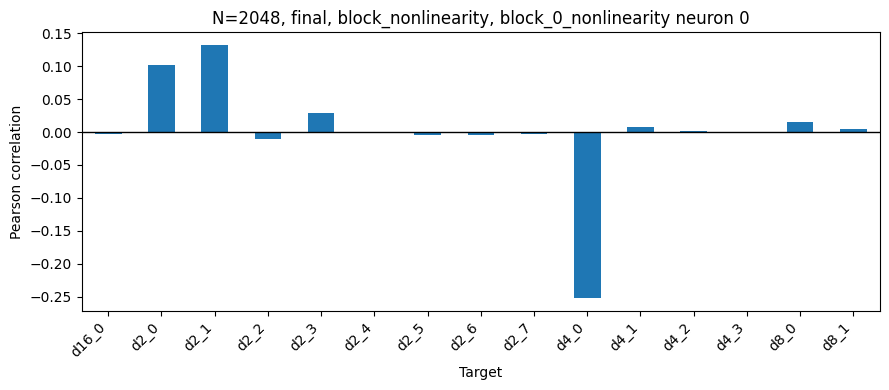

In [16]:
import matplotlib.pyplot as plt

SELECT_LAYER_IDX = 0
SELECT_NEURON_IDX = 0

if SELECT_LAYER_IDX not in correlation_by_layer:
    raise ValueError(f"SELECT_LAYER_IDX must be one of {list(correlation_by_layer)}")
selected_corr = correlation_by_layer[SELECT_LAYER_IDX]
if SELECT_NEURON_IDX < 0 or SELECT_NEURON_IDX >= selected_corr.shape[0]:
    raise ValueError(f"SELECT_NEURON_IDX must be in [0, {selected_corr.shape[0] - 1}]")

selected_neuron_correlations = pd.DataFrame(
    {
        "target": target_columns,
        "correlation": selected_corr[SELECT_NEURON_IDX].numpy(),
    }
)
selected_neuron_correlations["abs_correlation"] = selected_neuron_correlations["correlation"].abs()
selected_neuron_correlations = selected_neuron_correlations.sort_values(
    "abs_correlation",
    ascending=False,
)

layer_name = correlation_layer_names[SELECT_LAYER_IDX]
print(
    f"Correlations for N={CORRELATION_N}, {correlation_checkpoint_label}, "
    f"{CORRELATION_ACTIVATION_SOURCE}, {layer_name}, neuron {SELECT_NEURON_IDX}"
)
display(selected_neuron_correlations)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 4))
selected_neuron_correlations.sort_values("target").plot(
    x="target",
    y="correlation",
    kind="bar",
    legend=False,
    ax=ax,
)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("Target")
ax.set_ylabel("Pearson correlation")
ax.set_title(
    f"N={CORRELATION_N}, {correlation_checkpoint_label}, {CORRELATION_ACTIVATION_SOURCE}, "
    f"{layer_name} neuron {SELECT_NEURON_IDX}"
)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plot_path = (
    PLOTS_DIR
    / f"neuron_target_correlations_N_{CORRELATION_N}_{correlation_checkpoint_label}_{CORRELATION_ACTIVATION_SOURCE}_layer_{SELECT_LAYER_IDX}_neuron_{SELECT_NEURON_IDX}.png"
)
fig.savefig(plot_path, dpi=150)
print(f"Saved plot to {plot_path}")
plt.show()

## Thresholded Neuron-Target Correlation Counts

Choose a layer and threshold, then count neurons that are correlated with at least one output parity above that threshold.

In [ ]:
CORRELATION_LAYER_IDX_FOR_COUNTS = 0
CORRELATION_THRESHOLD_FOR_COUNTS = 0.1
USE_ABSOLUTE_CORRELATION_FOR_COUNTS = True

if not 0.0 <= CORRELATION_THRESHOLD_FOR_COUNTS <= 1.0:
    raise ValueError("CORRELATION_THRESHOLD_FOR_COUNTS must be between 0 and 1")
if CORRELATION_LAYER_IDX_FOR_COUNTS not in correlation_by_layer:
    raise ValueError(f"Layer must be one of {list(correlation_by_layer)}")

count_layer_corr = correlation_by_layer[CORRELATION_LAYER_IDX_FOR_COUNTS]
count_layer_name = correlation_layer_names[CORRELATION_LAYER_IDX_FOR_COUNTS]
count_layer_scores = count_layer_corr.abs() if USE_ABSOLUTE_CORRELATION_FOR_COUNTS else count_layer_corr
count_neuron_mask = (count_layer_scores > CORRELATION_THRESHOLD_FOR_COUNTS).any(dim=1)
count_neuron_indices = torch.nonzero(count_neuron_mask, as_tuple=False).flatten().tolist()
num_count_neurons = len(count_neuron_indices)
total_count_neurons = count_layer_corr.shape[0]

print(
    f"Layer {CORRELATION_LAYER_IDX_FOR_COUNTS} ({count_layer_name}), "
    f"source={CORRELATION_ACTIVATION_SOURCE}: "
    f"{num_count_neurons}/{total_count_neurons} neurons have at least one "
    f"{'absolute ' if USE_ABSOLUTE_CORRELATION_FOR_COUNTS else ''}"
    f"correlation > {CORRELATION_THRESHOLD_FOR_COUNTS}."
)


## Monosemanticity Table

For the selected layer, list neurons whose correlation with at least one output parity exceeds the threshold, together with the matching parity names and coefficients.

In [51]:
MONOSEMANTICITY_LAYER_IDX = 0
MONOSEMANTICITY_THRESHOLD = 0.1
MONOSEMANTICITY_USE_ABSOLUTE_CORRELATION = True

if not 0.0 <= MONOSEMANTICITY_THRESHOLD <= 1.0:
    raise ValueError("MONOSEMANTICITY_THRESHOLD must be between 0 and 1")
if MONOSEMANTICITY_LAYER_IDX not in correlation_by_layer:
    raise ValueError(f"Layer must be one of {list(correlation_by_layer)}")

monosemanticity_layer_corr = correlation_by_layer[MONOSEMANTICITY_LAYER_IDX]
monosemanticity_layer_name = correlation_layer_names[MONOSEMANTICITY_LAYER_IDX]
monosemanticity_layer_scores = (
    monosemanticity_layer_corr.abs()
    if MONOSEMANTICITY_USE_ABSOLUTE_CORRELATION
    else monosemanticity_layer_corr
)
monosemanticity_neuron_mask = (monosemanticity_layer_scores > MONOSEMANTICITY_THRESHOLD).any(dim=1)
monosemanticity_neuron_indices = torch.nonzero(
    monosemanticity_neuron_mask,
    as_tuple=False,
).flatten().tolist()

monosemanticity_rows = []
for neuron_idx in monosemanticity_neuron_indices:
    corr_values = monosemanticity_layer_corr[neuron_idx]
    score_values = monosemanticity_layer_scores[neuron_idx]
    hit_indices = torch.nonzero(score_values > MONOSEMANTICITY_THRESHOLD, as_tuple=False).flatten().tolist()
    hit_indices = sorted(hit_indices, key=lambda target_idx: score_values[target_idx].item(), reverse=True)
    correlated_targets = [target_columns[target_idx] for target_idx in hit_indices]
    correlated_coefficients = [corr_values[target_idx].item() for target_idx in hit_indices]
    monosemanticity_rows.append(
        {
            "layer_idx": MONOSEMANTICITY_LAYER_IDX,
            "layer": monosemanticity_layer_name,
            "activation_source": CORRELATION_ACTIVATION_SOURCE,
            "neuron_idx": neuron_idx,
            "num_correlated_outputs": len(hit_indices),
            "max_abs_correlation": corr_values.abs().max().item(),
            "correlated_outputs": ", ".join(correlated_targets),
            "correlation_coefficients": ", ".join(
                f"{target}: {coefficient:.4f}"
                for target, coefficient in zip(correlated_targets, correlated_coefficients)
            ),
        }
    )

monosemanticity_df = pd.DataFrame(monosemanticity_rows)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
threshold_label = str(MONOSEMANTICITY_THRESHOLD).replace(".", "p")
monosemanticity_csv_path = (
    ANALYSIS_DIR
    / f"monosemanticity_N_{CORRELATION_N}_{correlation_checkpoint_label}_{CORRELATION_ACTIVATION_SOURCE}_layer_{MONOSEMANTICITY_LAYER_IDX}_threshold_{threshold_label}.csv"
)
monosemanticity_df.to_csv(monosemanticity_csv_path, index=False)

if monosemanticity_df.empty:
    print(
        f"No neurons in layer {MONOSEMANTICITY_LAYER_IDX} ({monosemanticity_layer_name}) "
        f"passed threshold {MONOSEMANTICITY_THRESHOLD}."
    )
else:
    monosemanticity_df = monosemanticity_df.sort_values(
        ["num_correlated_outputs", "max_abs_correlation"],
        ascending=[True, False],
    )
    monosemanticity_df.to_csv(monosemanticity_csv_path, index=False)
    print(
        f"Layer {MONOSEMANTICITY_LAYER_IDX} ({monosemanticity_layer_name}), "
        f"source={CORRELATION_ACTIVATION_SOURCE}: "
        f"{len(monosemanticity_df)} neurons passed threshold {MONOSEMANTICITY_THRESHOLD}."
    )
    display(monosemanticity_df)
print(f"Saved monosemanticity table to {monosemanticity_csv_path}")


Layer 0 (block_0_nonlinearity), source=block_nonlinearity: 1408 neurons passed threshold 0.1.


,layer_idx,layer,activation_source,neuron_idx,num_correlated_outputs,max_abs_correlation,correlated_outputs,correlation_coefficients
294,0,block_0_nonlinearity,block_nonlinearity,437,1,0.572743,d2_1,d2_1: 0.5727
234,0,block_0_nonlinearity,block_nonlinearity,354,1,0.571664,d2_5,d2_5: -0.5717
1092,0,block_0_nonlinearity,block_nonlinearity,1597,1,0.568588,d2_3,d2_3: 0.5686
352,0,block_0_nonlinearity,block_nonlinearity,508,1,0.568467,d2_0,d2_0: -0.5685
653,0,block_0_nonlinearity,block_nonlinearity,942,1,0.567316,d2_1,d2_1: 0.5673
...,...,...,...,...,...,...,...,...
555,0,block_0_nonlinearity,block_nonlinearity,804,3,0.187372,"d4_0, d2_0, d2_1","d4_0: -0.1874, d2_0: -0.1730, d2_1: -0.1290"
1181,0,block_0_nonlinearity,block_nonlinearity,1721,3,0.147158,"d2_6, d4_3, d2_7","d2_6: -0.1472, d4_3: 0.1116, d2_7: 0.1048"
445,0,block_0_nonlinearity,block_nonlinearity,646,3,0.147088,"d2_3, d2_2, d4_1","d2_3: 0.1471, d2_2: -0.1218, d4_1: 0.1161"
5,0,block_0_nonlinearity,block_nonlinearity,6,3,0.143376,"d2_2, d4_1, d2_3","d2_2: -0.1434, d4_1: -0.1357, d2_3: -0.1242"


Saved monosemanticity table to /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_mup_4blocks/analysis/monosemanticity_N_2048_final_block_nonlinearity_layer_0_threshold_0p1.csv


## Proportion Correlated With One Output

For a chosen layer and output parity name, compute the proportion of neurons whose correlation with that output exceeds the threshold.

In [50]:
PROPORTION_LAYER_IDX = 3
OUTPUT_PARITY = "d16_0"
PROPORTION_THRESHOLD = 0.1
PROPORTION_USE_ABSOLUTE_CORRELATION = True

if not 0.0 <= PROPORTION_THRESHOLD <= 1.0:
    raise ValueError("PROPORTION_THRESHOLD must be between 0 and 1")
if PROPORTION_LAYER_IDX not in correlation_by_layer:
    raise ValueError(f"Layer must be one of {list(correlation_by_layer)}")
if OUTPUT_PARITY not in target_columns:
    raise ValueError(f"OUTPUT_PARITY must be one of {target_columns}")

proportion_corr = correlation_by_layer[PROPORTION_LAYER_IDX]
proportion_layer_name = correlation_layer_names[PROPORTION_LAYER_IDX]
target_idx = target_columns.index(OUTPUT_PARITY)
output_corr = proportion_corr[:, target_idx]
output_scores = output_corr.abs() if PROPORTION_USE_ABSOLUTE_CORRELATION else output_corr
output_neuron_mask = output_scores > PROPORTION_THRESHOLD
output_neuron_indices = torch.nonzero(output_neuron_mask, as_tuple=False).flatten().tolist()
output_num_neurons = len(output_neuron_indices)
output_total_neurons = output_corr.shape[0]
output_proportion = output_num_neurons / output_total_neurons

print(
    f"Layer {PROPORTION_LAYER_IDX} ({proportion_layer_name}), source={CORRELATION_ACTIVATION_SOURCE}, "
    f"output={OUTPUT_PARITY}: {output_num_neurons}/{output_total_neurons} neurons "
    f"({output_proportion:.4f}) have "
    f"{'absolute ' if PROPORTION_USE_ABSOLUTE_CORRELATION else ''}correlation > {PROPORTION_THRESHOLD}."
)

output_proportion_df = pd.DataFrame(
    {
        "layer_idx": [PROPORTION_LAYER_IDX],
        "layer": [proportion_layer_name],
        "activation_source": [CORRELATION_ACTIVATION_SOURCE],
        "output_parity": [OUTPUT_PARITY],
        "threshold": [PROPORTION_THRESHOLD],
        "use_absolute_correlation": [PROPORTION_USE_ABSOLUTE_CORRELATION],
        "num_neurons": [output_num_neurons],
        "total_neurons": [output_total_neurons],
        "proportion": [output_proportion],
    }
)
display(output_proportion_df)


Layer 3 (block_3_nonlinearity), source=block_nonlinearity, output=d16_0: 19/2048 neurons (0.0093) have absolute correlation > 0.1.


,layer_idx,layer,activation_source,output_parity,threshold,use_absolute_correlation,num_neurons,total_neurons,proportion
0,3,block_3_nonlinearity,block_nonlinearity,d16_0,0.1,True,19,2048,0.009277
